In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra
using DifferentialEquations, StaticArrays

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [ ]:
xgrid = range(0, 200, length=200)

ybottom = [wall_y(x, 50, 100, 110) for x in xgrid]

dy = diff(ybottom)

threshold = 1e-6

left_walls  = falses(length(xgrid))
right_walls = falses(length(xgrid))

for i in 2:length(dy)
    if dy[i] > threshold
        left_walls[i] = true
    elseif dy[i] < -threshold
        right_walls[i] = true
    end

end


In [704]:
collective_neg_pos_model = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :S => Float64,
        # :S_2 => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64,
        :M => Float64,
        :Ds => Float64

        # :xs => Float64,
        # :ys => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64
    ),

    medium = Dict(
        :mm => Float64,
        :ve => Float64
    ),

    agentODE = quote
  
        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]


        idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        
        # X direction
        if x < xmin
            idx = Int(floor(Int, (x+(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        #     x += (xmax - xmin)
        elseif x > xmax
            idx = Int(floor(Int, (x-(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        #     x -= (xmax - xmin)
        end

        # # Y direction
        if y < ymin
            idy = Int(floor(Int,(y+ymax-ymin)/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        #     y += (ymax - ymin)
        elseif y > ymax
            idy = Int(floor(Int,(y-(ymax-ymin))/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        #     y -= (ymax - ymin)
        end

        mmb = mm[idx,idy]

        F = ε0 + ε1 * methyl + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka))
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)      

        mx = (ε0 + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka)) - F0) / (- ε1)
       

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = vx  #Change position acording to constant speed afected by forces
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote

        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]
        idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)        
       
     # Adding population every 100 steps
        # if i1_ == 1
        #     step = round(Int, t/dt)
        #     if step % 1000 == 0
                
        #         for k in 1:4
        #             @addAgent(
        #                 x = (xmax-xmin)/2,   # small offset inside domain
        #                 y = ymax/2 + 12 + rand()*(ymax - (ymax/2)),
        #                 l = 3
        #             )
        #         end
        #     end
        # end

        v_run = v
        v_tumble = 0.25 

        speed = active ? v_run : v_tumble

        Dr_tumble = 6.2      
        Dr_total = active ? Dr_run : Dr_tumble

        mm[idx,idy] += S

        if active 
            λ = ωFrec*exp(-G)
            P = 1 - exp(-λ * dt)
                
        else
            λ = ωFrec*exp(G)
            P = 1 - exp(-λ * dt)  
                
        end


        if active 
            λrt = ωFrec*exp(-G) 

            P_rt = 1 - exp(-λrt * dt)
            P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
            if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                active = false
                vx = speed* cos(theta) + ve[idx, idy]*0.5
                vy = speed* sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
            else     #Si rate baixa 
                active = true
                vx = speed * cos(theta) + ve[idx, idy]*0.5
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
            end

        else
            λtr = ωFrec*exp(G) 
            P_tr = 1 - exp(-λtr * dt)
            P = rand()

            if P < P_tr
                active = true
                vx = speed * cos(theta) + ve[idx, idy]*0.5
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            else
                active = false
                vx = speed* cos(theta) + ve[idx, idy]*0.5
                vy = speed* sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            end
        end

        if x < xmin
            x = xmin + (xmin - x)
            vx = -vx
        elseif x >= xmax
            @removeAgent()
        end

        if y > ymax
            y = 2*ymax - y
            vy = -vy
        end

        if y <= wall_y(x, 50, 100, 110)
            if left_walls[round(Int, x)] == 1
                vx = -vx
            elseif right_walls[round(Int, x)] == 1
                vx = -vx
            else
                vy = -vy
            end
        end



    end,


    mediumODE = quote

        if @mediumInside()

    # --- geometry mask FIRST (do NOT overwrite mm itself) ---
            if M0[i1_, i2_]

                dt(mm) = 0

            else
                
                dt(mm) = DMedium * (@∂2(1, mm) + @∂2(2, mm)) - delta * mm - ve[i1_, i2_] * @∂(1, mm)

            end
            
            mm = MXR[i1_, i2_] ? mm[i1_ + 1, i2_] : mm
            mm = MXL[i1_, i2_] ? mm[i1_ - 1, i2_] : mm
            mm = MYT[i1_, i2_] ? mm[i1_, i2_ + 1] : mm

            
        elseif @mediumBorder(1,-1) # left PBC
            mm = mm[1, i2_]

        elseif @mediumBorder(1,1) #right PBC
            mm = mm[NMedium[1] - 1, i2_]

        elseif @mediumBorder(2,-1) # down NBC (newmann)
            mm = 0

        elseif @mediumBorder(2,+1)
            mm = mm[i1_, NMedium[2] - 1]

        end
    end,


    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler()
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	xₘ (Float64 medium)
	yₘ (Float64 medium)
	Ds (Float64 agent)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)
	mm (Float64 medium)
	ve (Float64 medium)


UPDATE RULES
mediumODE
 if @mediumInside()
    if

In [697]:
dx = (com.simBox[1,2] - com.simBox[1,1]) / com.NMedium[1]
dy = (com.simBox[2,2] - com.simBox[2,1]) / com.NMedium[2]

xcoord(i1_) = com.simBox[1,1] + (i1_ - 1) * dx
ycoord(i2_) = com.simBox[2,1] + (i2_ - 1) * dy
Nx = com.NMedium[1]
Ny = com.NMedium[2]

mask_raw = zeros(Bool, com.NMedium[1], com.NMedium[2])
M0 = zeros(Bool, com.NMedium[1], com.NMedium[2])
MXL = zeros(Bool, com.NMedium[1], com.NMedium[2])
MXR = zeros(Bool, com.NMedium[1], com.NMedium[2])
MYT = zeros(Bool, com.NMedium[1], com.NMedium[2])

for i in 1:Nx, j in 1:Ny
    x = xcoord(i)
    y = ycoord(j)
    mask_raw[i,j] = y < wall_y(x)
end

for i in 2:Nx-1, j in 2:Ny-1
    if mask_raw[i,j] &&
       mask_raw[i+1,j] &&
       mask_raw[i-1,j] &&
       mask_raw[i,j+1] &&
       mask_raw[i,j-1]

        M0[i,j] = true
    end
end

for i in 2:Nx-1, j in 2:Ny-1

    if M0[i,j] == 1

        # --- HORIZONTAL LINES ---
        # bottom edge (neighbor below is outside)
        if M0[i, j-1] == 0
            MYT[i,j] = true
        end

        # top edge (neighbor above is outside)
        if M0[i, j+1] == 0
            MYT[i,j] = true
        end


        # --- LEFT WALL ---
        if M0[i-1, j] == 0
            MXL[i,j] = true
        end


        # --- RIGHT WALL ---
        if M0[i+1, j] == 0
            MXR[i,j] = true
        end

    end
end

In [705]:
com = Community(
    collective_neg_pos_model,
    N=10,
    dt=0.01,
    # simBox = [-100.0 100.0; -100.0 100.0],
    simBox = [0.0 200.0; 0.0 200.0],
    NMedium = [100,100]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

com.v = 20.0    #Velocitat bacteries biològica
# com.v = 10.0
# com.v = 0
# com.v = 5.0
# com.v = 2.5
# com.v = 1
# com.v = 0.1

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.τm = 1
# com.τm = 5.0
# com.τm = 10.0
# com.τm = 30.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.DMedium = 100
com.delta = 0.00125
# com.ve = 10

# com.x = rand(Uniform(com.simBox[1,:]...),com.N)
com.x = 125
# com.y = rand(Uniform(com.simBox[2,:]...),com.N)
com.y = 150

com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K

com.active .= true 
com.S = 1


1

In [706]:
com.ve = zeros(com.NMedium[1], com.NMedium[2])

for i1 in 1:com.NMedium[1], i2 in 1:com.NMedium[2]
    y = ycoord(i2)

    if y > 100
        com.ve[i1, i2] = 10
    else
        com.ve[i1, i2] = 0.0
    end
end

In [655]:
function wall_y(x, w, d, y0; xstart = 10.0, xend=200.0)
    
    # outside wall region → flat at baseline
    if x < xstart || x > xend
        return y0
    end

    # shift x so pattern starts at xstart
    ξ = x - xstart

    # square-wave pattern (0 or -d), then shift up by y0
    return y0 - d * floor((1 + sign(sin(2π * ξ / w))) / 2)
end

function wall_bottom(x, x1, x2, y0, depth)
    if x1 ≤ x ≤ x2
        return y0 - depth   # invagination
    else
        return y0           # flat
    end
end

function in_left_wall(x, y, x1, y0, depth)
    return abs(x - x1) < 1e-6 && y0 - depth ≤ y ≤ y0
end

function in_right_wall(x, y, x2, y0, depth)
    return abs(x - x2) < 1e-6 && y0 - depth ≤ y ≤ y0
end

in_right_wall (generic function with 1 method)

In [707]:
outfile = "cript_test.jld2"
steps = 10000

loadToPlatform!(com, preallocateAgents=10)
com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    # -------------------------
    # Metadata (written once)
    # -------------------------
    # meta = JLD2.Group(file, "meta")
    # meta["N"] = com.N
    # meta["NMedium"] = com.NMedium
    # meta["steps"] = steps

    # -------------------------
    # Main loop
    # -------------------------
    for step in 1:steps
        CellBasedModels.step!(com)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
        g["theta"] = copy(com.theta)

        # Medium grid (saved once per step)
        g["mm_grid"] = copy(com.mm)
    end
end


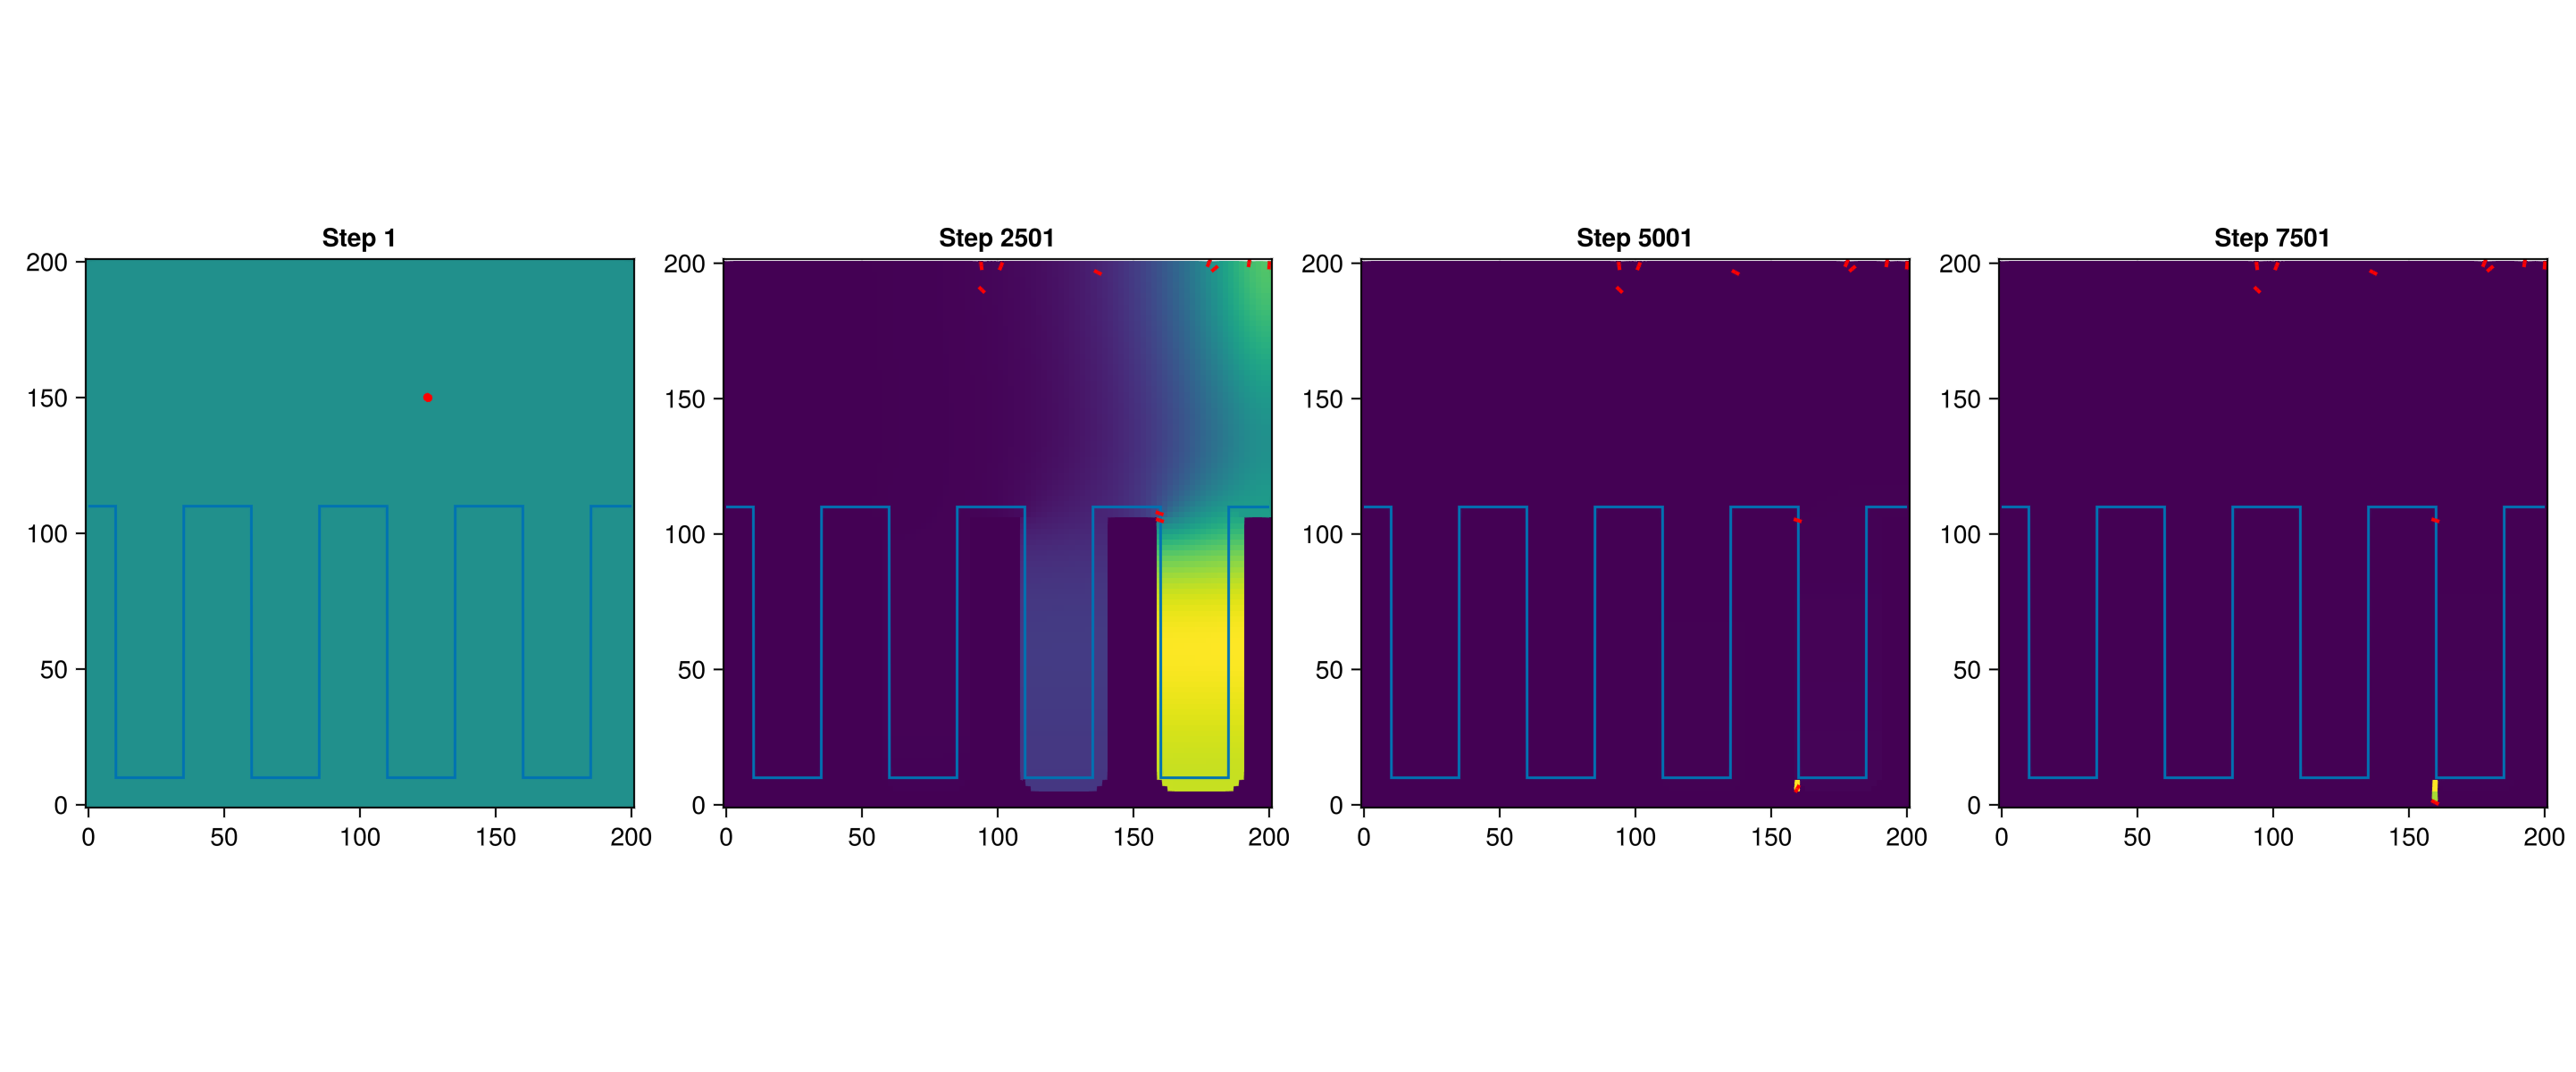

GLMakie.Screen(...)

In [709]:
fig4 = Figure(size=(900*4,600))
steps = 10000
model_steps = 1:steps
steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/4):end]
# steps_to_plot = [1, 100, 200, 300]

jldopen("cript_test.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        row = ceil(Int, j / 4)
        col = (j - 1) % 4 + 1

        ax = Axis(fig4[row, col], aspect=1, title="Step $step")

        g = file[@sprintf("step_%06d", step)]
    
        mm_grid = g["mm_grid"]
        mm = reshape(mm_grid, (100,100))

        hm = heatmap!(ax, 
                    range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                    range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                    mm_grid, 
                    colormap=:viridis
                    )

        xs = 0:0.1:200
        ys = [wall_y(x) for x in xs]

        lines!(ax, xs, ys)


        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3
            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            if x[i] != 0
                linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
                linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
            end
        end

        # Colorbar(fig4[1, 2*j], hm, label="Chemoattractant")

    end
end

display(fig4)

In [710]:
data = Dict{Int, Any}()
steps = 1000
jldopen("cript_test.jld2", "r") do file
    for step in 1:steps
        key = file[@sprintf("step_%06d", step)]
        data[step] = Dict(
            "x" => copy(key["x"]),
            "y" => copy(key["y"]),
            "theta" => copy(key["theta"]),
            # "l" => copy(key["l"]),
            "mm_grid" => copy(key["mm_grid"])
        )
    end
end

# Setup plot
fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1], aspect=1, title="Step 1", xlabel="x (μm)", ylabel="y (μm)")

# Initialize scatter and lines
scatter_plt = scatter!(ax, Float64[], Float64[], color=:red, markersize=5, label="Bacteria")
# source_plt = scatter!(ax, [0.0], [0.0], color=:cyan, markersize=5, label="Source")

# Slider
slider = Slider(fig[2, 1:2], range=1:steps, startvalue=1, update_while_dragging = true)
Label(fig[2, 3], "Step: ", fontsize=14)

# Update function
function update_plot(step)
    empty!(ax)

    g = data[step]
    mm_grid = g["mm_grid"]
    mm = reshape(mm_grid, (100,100))

    hm = heatmap!(ax, 
                range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                mm_grid, 
                colormap=:viridis
                    )

    # Colorbar(fig[1, 2], hm, label="mm (μM)")

    
    x = g["x"]
    y = g["y"]
    theta = g["theta"]
    l = 3

    # Update scatter
    scatter_plt[1] = x
    scatter_plt[2] = y

    # Compute rod endpoints
    xs1 = x .+ l ./ 2 .* cos.(theta)
    ys1 = y .+ l ./ 2 .* sin.(theta)
    xs2 = x .- l ./ 2 .* cos.(theta)
    ys2 = y .- l ./ 2 .* sin.(theta)
    
    for i in 1:length(x)
        linesegments!(ax, [Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
        linesegments!(ax, [Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
    end

    # Update title
    ax.title = "Step $step"

    # Redraw
    autolimits!(ax)
end

# Connect slider to update
on(slider.value) do val
    update_plot(Int(val))
end

# Initialize
update_plot(1)

# Display
# display(fig)

GLMakie.activate!()
display(fig)

GLMakie.Screen(...)

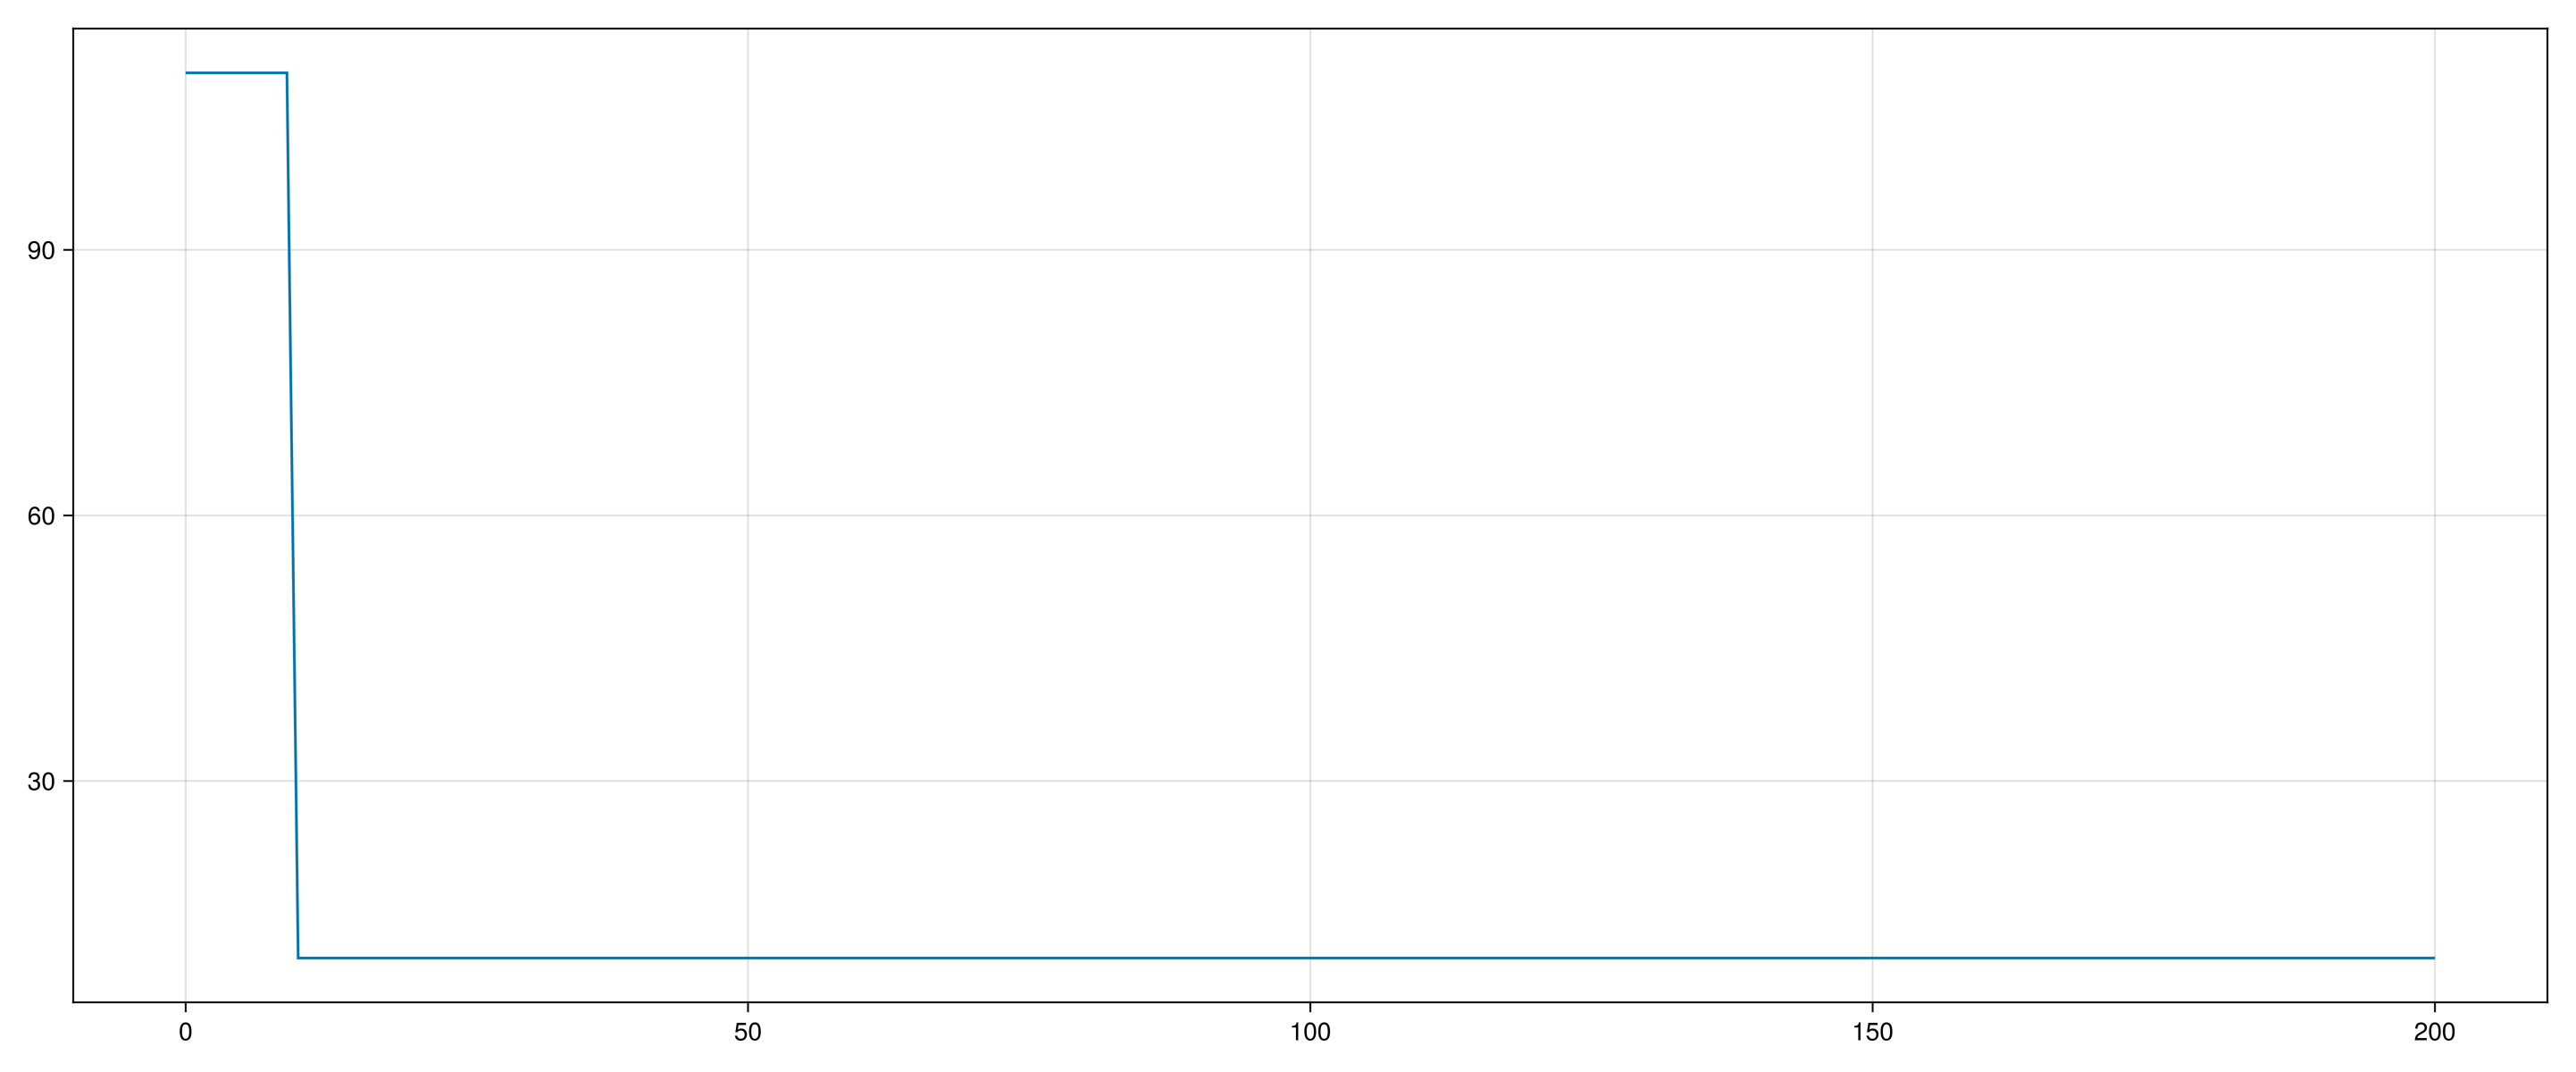

In [666]:
fig3 = Figure(size=(2100,600))
ax3 = Axis(fig3[1,1])
# ax3_2 = Axis(fig3[1,2])
# ax3_3 = Axis(fig3[1,3])
# hm = heatmap!(ax3, M0)
# hm_1 = heatmap!(ax3_2, mask)
# hm_2 = heatmap!(ax3_3, MXL)
# contour!(ax3_2, M0, linewidth = 0.5)
# contour!(ax3_3, M0, linewidth = 0.5)
# contour!(ax3, MXR, linewidth = 0.5)
# contour!(ax3, MXL, linewidth = 0.5)
# contour!(ax3, MYT, linewidth = 0.5)
xs = 0:1:200
# ys = 0:1:200
ys = [wall_bottom(x,10, 200, 110, 100) for x in xs]
lines!(ax3, xs, ys)
# hm = heatmap!(ax3, Z)
Makie.inline!(true)

fig3

In [19]:
function is_wall(x, y; w=10, d=20)
    # Base wall at y = 0
    if y == 0
        return iseven(fld(x, w))  # alternating solid / gap
    end

    # Indentations going downward
    if y < 0
        return isodd(fld(x, w)) && y >= -d
    end

    return false
end

is_wall (generic function with 1 method)

In [ ]:
function wall_y_test(x; w=10.0, d=20.0)
    return -d * floor((1 + sign(sin(2π * x / w))) / 2)
end


wall_y (generic function with 1 method)

In [55]:
function wall_y(x; xstart=20.0, xend=180.0, w=10.0, d=20.0)
    
    # outside wall region → no wall (or treat as flat boundary)
    if x < xstart || x > xend
        return 0.0
    end

    # shift x so pattern starts at xstart
    ξ = x - xstart

    return -d * floor((1 + sign(sin(2π * ξ / w))) / 2)
end

wall_y (generic function with 1 method)

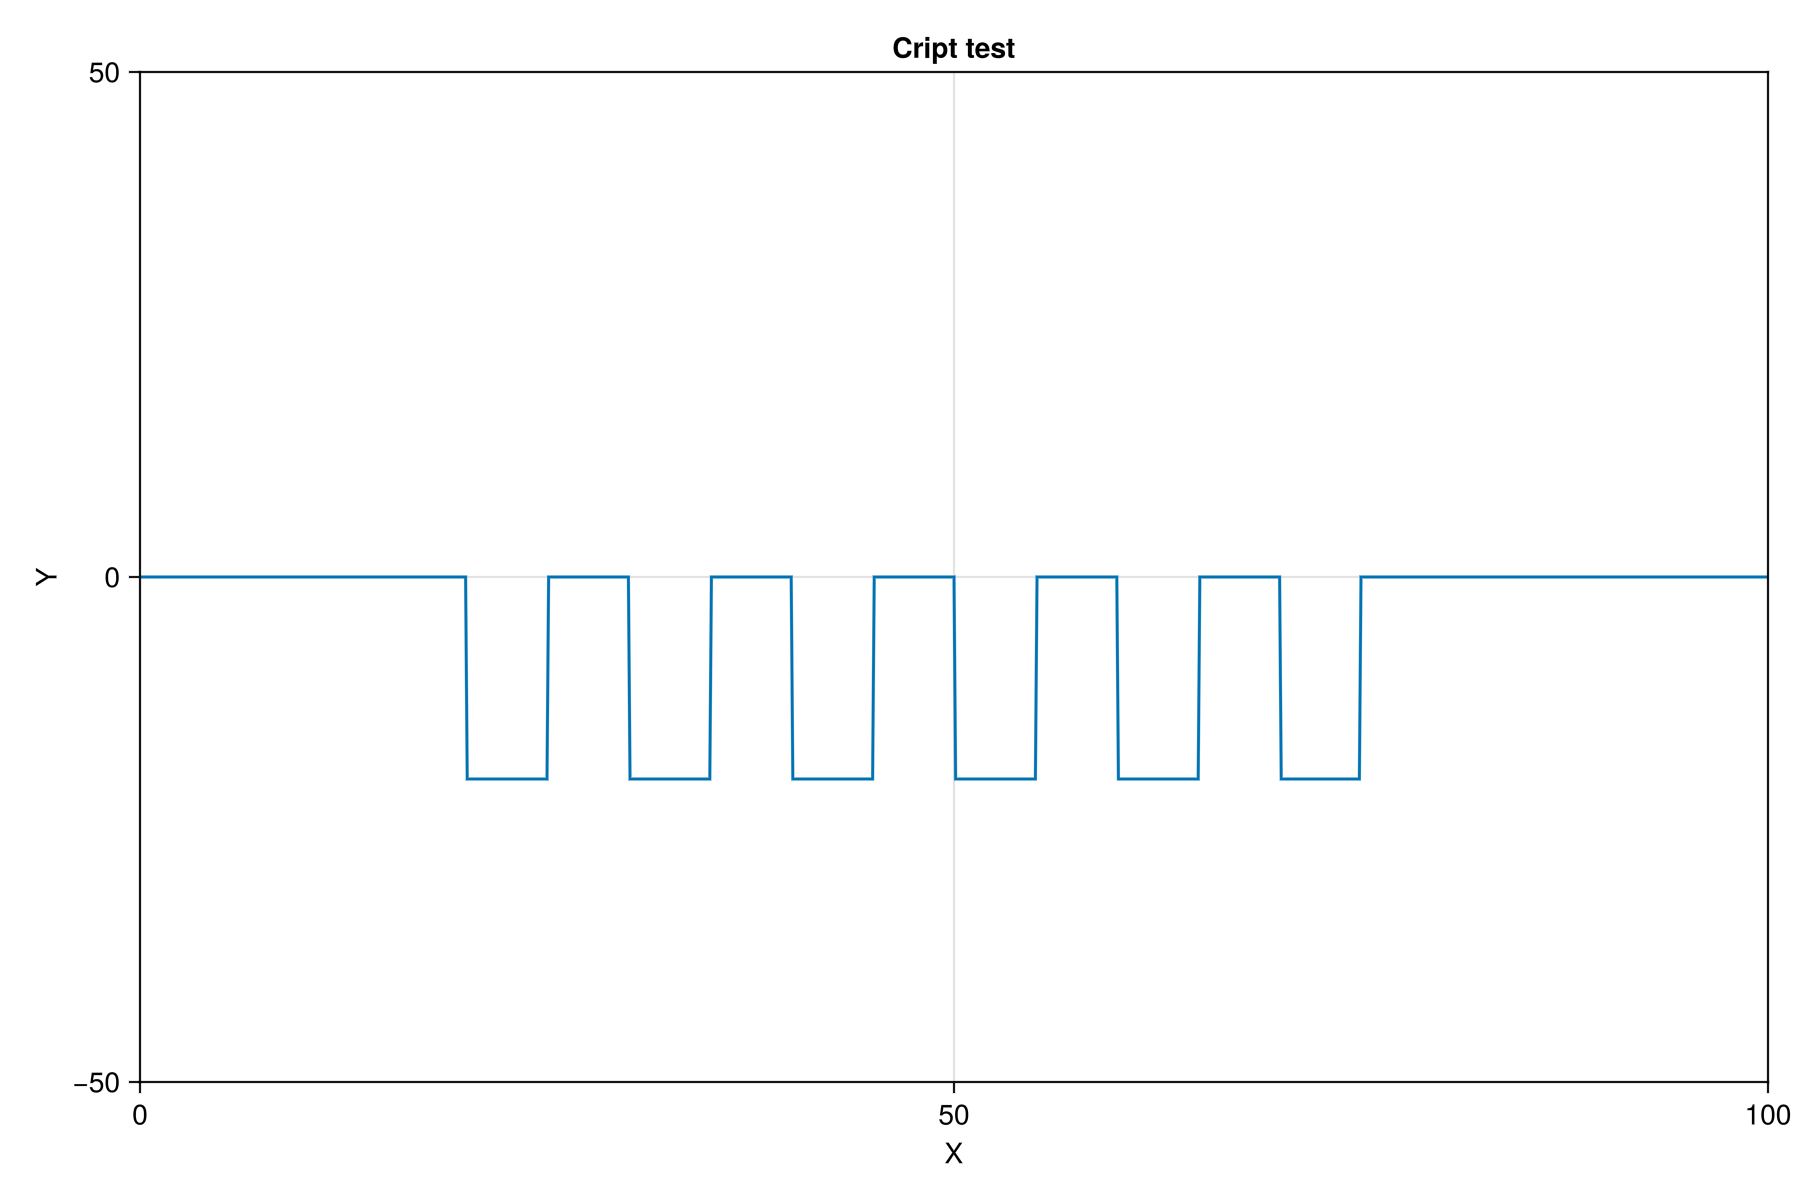

In [27]:
fig = Figure(size=(900,600))
ax = Axis(fig[1,1], title = "Cript test", xlabel = "X", ylabel = "Y")

xs = 0:0.1:100
ys = [wall_y(x) for x in xs]

lines!(ax, xs, ys)
xlims!(ax, 0, 100)
ylims!(ax, -50, 50)
fig

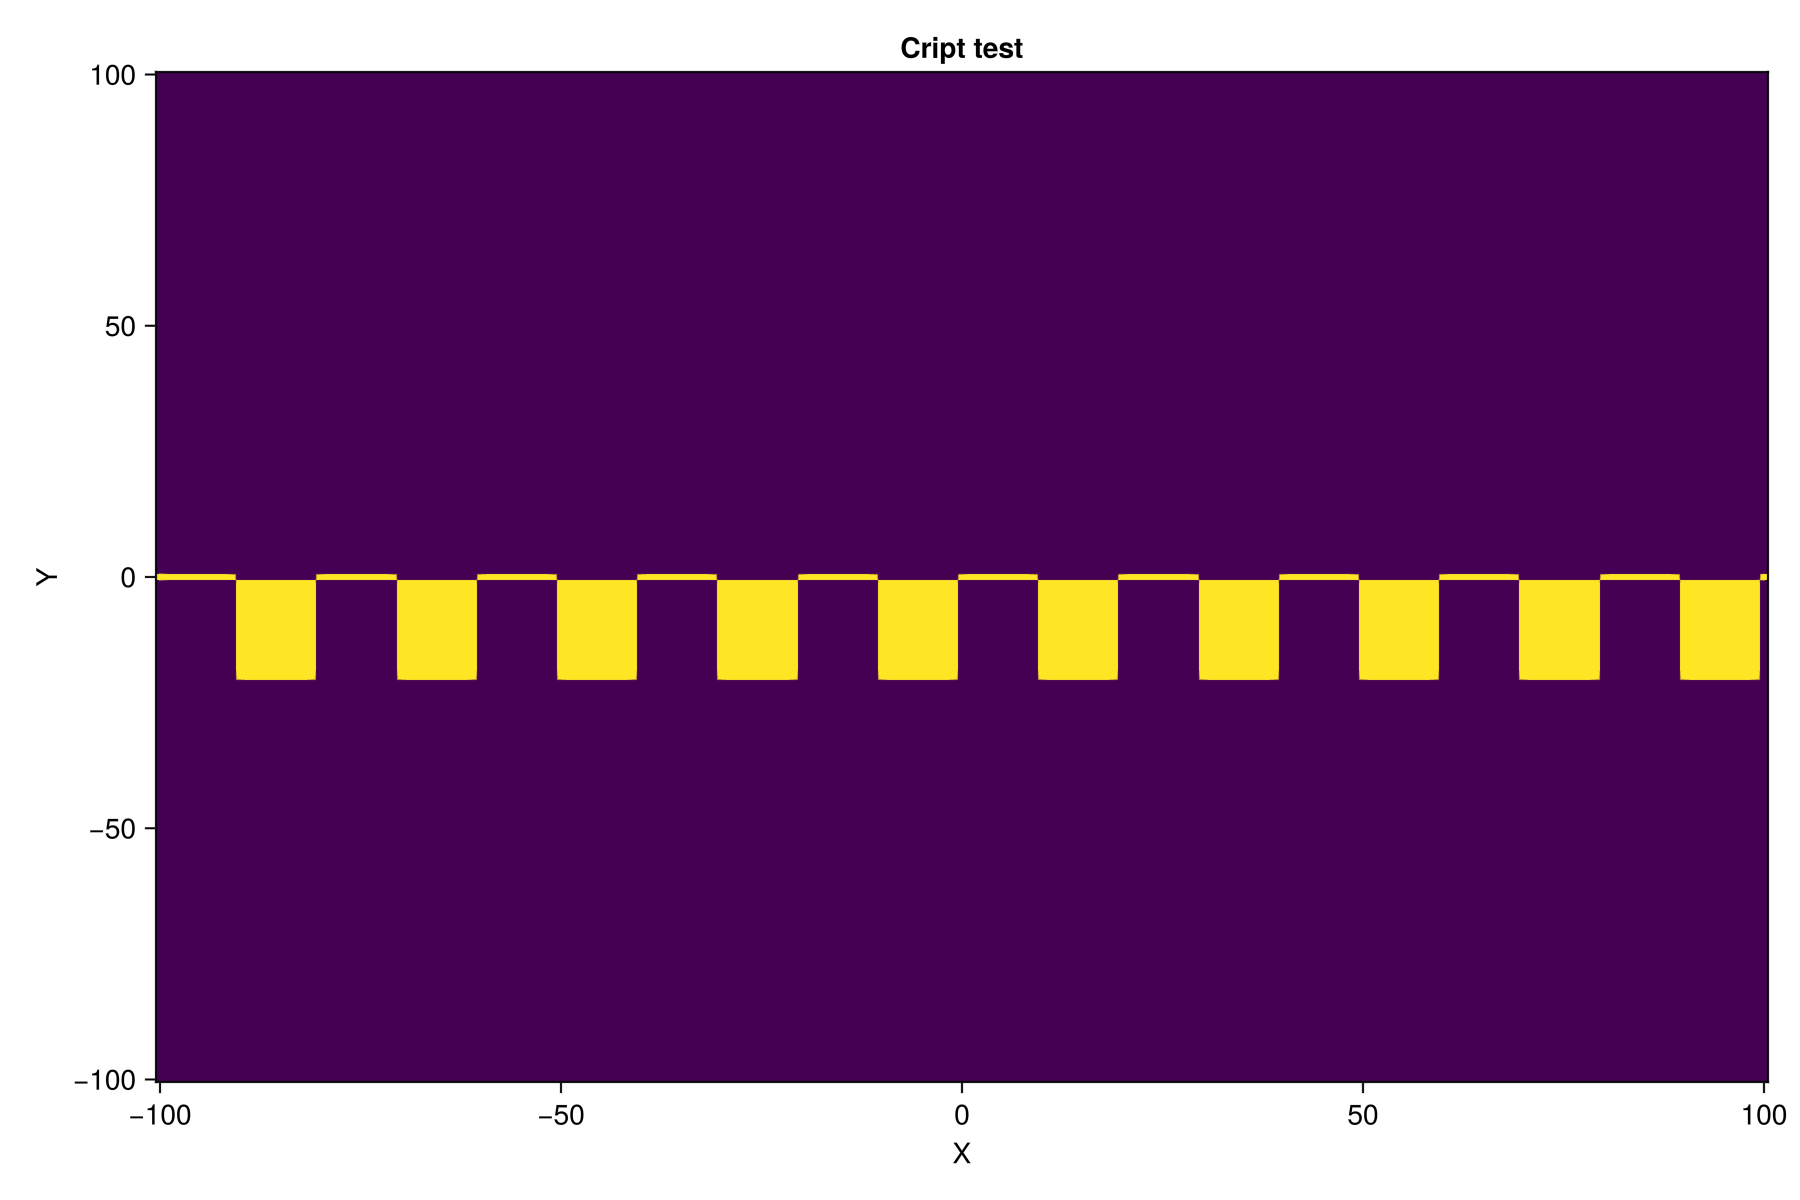

In [20]:
fig2 = Figure(size=(900,600))
ax2 = Axis(fig2[1,1], title = "Cript test", xlabel = "X", ylabel = "Y")

xs = -100:1:100
ys = -100:1:100
Z = [is_wall(x, y) ? 1.0 : 0.0 for x in xs, y in ys]
heatmap!(ax2, xs, ys, Z)
fig2

# test

In [ ]:
padding = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :S => Float64,
        # :S_2 => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64,
        :M => Float64,
        :Ds => Float64

        # :xs => Float64,
        # :ys => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64
    ),

    medium = Dict(
        :mm => Float64,
        :ve => Float64
    ),

    agentODE = quote
  
        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]


        idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        
        # X direction
        if x < xmin
            idx = Int(floor(Int, (x+(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        #     x += (xmax - xmin)
        elseif x > xmax
            idx = Int(floor(Int, (x-(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        #     x -= (xmax - xmin)
        end

        # # Y direction
        if y < ymin
            idy = Int(floor(Int,(y+ymax-ymin)/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        #     y += (ymax - ymin)
        elseif y > ymax
            idy = Int(floor(Int,(y-(ymax-ymin))/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        #     y -= (ymax - ymin)
        end

        mmb = mm[idx,idy]

        F = ε0 + ε1 * methyl + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka))
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)      

        mx = (ε0 + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka)) - F0) / (- ε1)
       

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = vx  #Change position acording to constant speed afected by forces
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote

        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]
        
        # Adding population every 100 steps
        if i1_ == 1
            step = round(Int, t/dt)
            if step % 1000 == 0
                
                for k in 1:4
                    @addAgent(
                        x = xmin + 0.01*(xmax - xmin),   # small offset inside domain
                        y = ymax/2 + 12 + rand()*(ymax - (ymax/2)),
                        l = 3
                    )
                end
            end
        end

        v_run = v
        v_tumble = 0.25 

        speed = active ? v_run : v_tumble

        Dr_tumble = 6.2      
        Dr_total = active ? Dr_run : Dr_tumble

        mm[idx,idy] += S

        if active 
            λ = ωFrec*exp(-G)
            P = 1 - exp(-λ * dt)
                
        else
            λ = ωFrec*exp(G)
            P = 1 - exp(-λ * dt)  
                
        end


        if active 
            λrt = ωFrec*exp(-G) 

            P_rt = 1 - exp(-λrt * dt)
            P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
            if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                active = false
                vx = speed* cos(theta)
                vy = speed* sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
            else     #Si rate baixa 
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
            end

        else
            λtr = ωFrec*exp(G) 
            P_tr = 1 - exp(-λtr * dt)
            P = rand()

            if P < P_tr
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            else
                active = false
                vx = speed* cos(theta)
                vy = speed* sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            end
        end

        ϵ = 1e-6

        if x <= xmin
            x = xmin + ϵ
            vx = abs(vx)
        elseif x >= xmax
            @removeAgent()
        end

        if y >= ymax
            y = ymax - ϵ
            vy = -abs(vy)
        end

            # # Bottom wall (geometry)
        if y <= wall_y(x, 50, 100, 110)
            y = wall_y(x, 50, 100, 110)
            vy = -vy
        end

    end,


    mediumODE = quote

        if @mediumInside()

    # --- geometry mask FIRST (do NOT overwrite mm itself) ---
            if M0[i1_, i2_]

                dt(mm) = 0

            else
                
                dt(mm) = DMedium * (@∂2(1, mm) + @∂2(2, mm)) - delta * mm + ve[i1_, i2_] * @∂(1, mm)

            end
            
            mm = MXR[i1_, i2_] ? mm[i1_ - 1, i2_] : mm
            mm = MXL[i1_, i2_] ? mm[i1_ + 1, i2_] : mm
            mm = MYT[i1_, i2_] ? mm[i1_, i2_ - 1] : mm

            
        elseif @mediumBorder(1,-1) # left PBC
            mm = mm[1, i2_]

        elseif @mediumBorder(1,1) #right PBC
            mm = mm[NMedium[1] - 1, i2_]

        elseif @mediumBorder(2,-1) # down NBC (newmann)
            mm = 0

        elseif @mediumBorder(2,+1)
            mm = mm[i1_, NMedium[2] - 1]

        end
    end,


    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler()
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	xₘ (Float64 medium)
	yₘ (Float64 medium)
	Ds (Float64 agent)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)
	mm (Float64 medium)
	ve (Float64 medium)


UPDATE RULES
mediumODE
 if @mediumInside()
    if

In [548]:
com = Community(
    padding,
    N=1,
    dt=0.01,
    simBox = [0.0 200.0; 0.0 200.0],
    NMedium = [100,100]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

com.v = 20.0    #Velocitat bacteries biològica
# com.v = 10.0
# com.v = 0
# com.v = 5.0
# com.v = 2.5
# com.v = 1
# com.v = 0.1

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.τm = 1
# com.τm = 5.0
# com.τm = 10.0
# com.τm = 30.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.DMedium = 20
com.delta = 0.00125
# com.ve = 10

# com.x = rand(Uniform(com.simBox[1,:]...),com.N)
com.x = 100
# com.y = rand(Uniform(com.simBox[2,:]...),com.N)
com.y = 180

com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K

com.active .= true 
com.S = 1

com.ve = zeros(com.NMedium[1], com.NMedium[2])

for i1 in 1:com.NMedium[1], i2 in 1:com.NMedium[2]
    y = ycoord(i2)

    if y > 100
        com.ve[i1, i2] = -0.4
    else
        com.ve[i1, i2] = 0.0
    end
end

In [549]:
outfile = "cript_test_2.jld2"
steps = 10000

loadToPlatform!(com, preallocateAgents=1000)
com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    # -------------------------
    # Metadata (written once)
    # -------------------------
    # meta = JLD2.Group(file, "meta")
    # meta["N"] = com.N
    # meta["NMedium"] = com.NMedium
    # meta["steps"] = steps

    # -------------------------
    # Main loop
    # -------------------------
    for step in 1:steps
        CellBasedModels.step!(com)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
        g["theta"] = copy(com.theta)

        # Medium grid (saved once per step)
        g["mm_grid"] = copy(com.mm)
    end
end


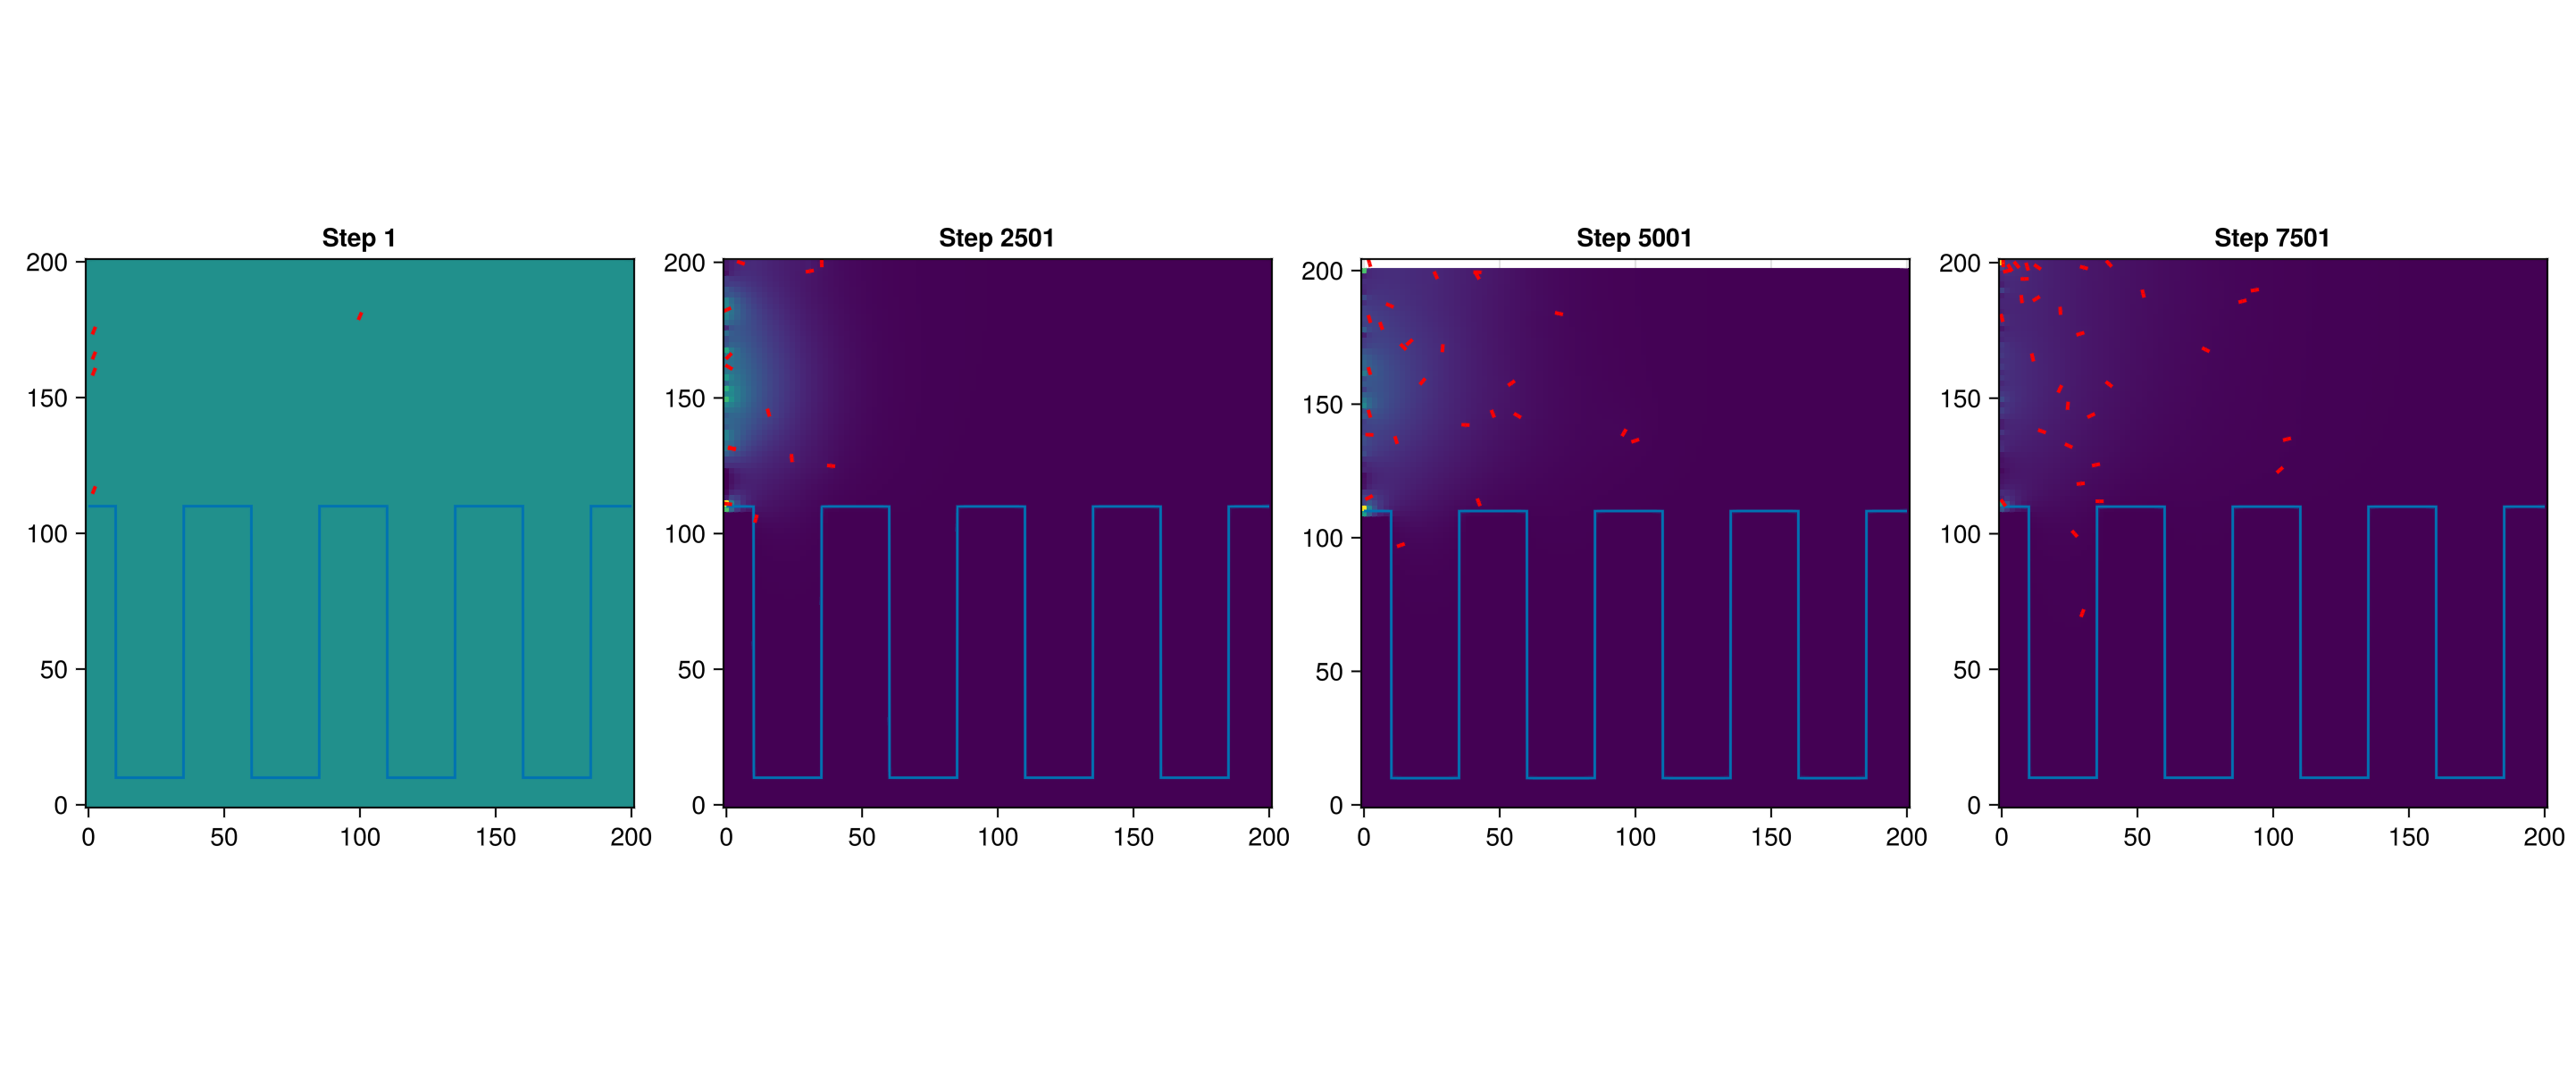

GLMakie.Screen(...)

In [550]:
fig4 = Figure(size=(900*4,600))
steps = 10000
model_steps = 1:steps
steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/4):end]
# steps_to_plot = [1, 100, 200, 300]

jldopen("cript_test_2.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        row = ceil(Int, j / 4)
        col = (j - 1) % 4 + 1

        ax = Axis(fig4[row, col], aspect=1, title="Step $step")

        g = file[@sprintf("step_%06d", step)]
    
        mm_grid = g["mm_grid"]
        mm = reshape(mm_grid, (100,100))

        hm = heatmap!(ax, 
                    range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                    range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                    mm_grid, 
                    colormap=:viridis
                    )

        xs = 0:0.1:200
        ys = [wall_y(x) for x in xs]

        lines!(ax, xs, ys)


        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3
            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            if x[i] != 0
                linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
                linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
            end
        end

        # Colorbar(fig4[1, 2*j], hm, label="Chemoattractant")

    end
end

display(fig4)

In [676]:
xgrid = range(0, 200, length=200)

ybottom = [wall_y(x, 50, 100, 110) for x in xgrid]
ybottom[10:50]

41-element Vector{Real}:
 110
  10.0
  10.0
  10.0
  10.0
  10.0
  10.0
  10.0
  10.0
  10.0
   ⋮
 110.0
 110.0
 110.0
 110.0
 110.0
 110.0
 110.0
 110.0
 110.0

In [ ]:
dy = diff(ybottom)

threshold = 1e-6

left_walls  = falses(length(xgrid))
right_walls = falses(length(xgrid))

for i in 2:length(dy)
    if dy[i] > threshold
        left_walls[i] = true
    elseif dy[i] < -threshold
        right_walls[i] = true
    end

end


4-element BitVector:
 1
 1
 1
 1